In [2]:
import torch
import time
import matplotlib.pyplot as plt
import numpy as np
from thop import profile
from models.nn_regressors import MLP, LSTM, EEGNet, DeepFingerNet, CNN_LSTM, WaT, WaTEi, HiLoFuseNet, Conv2dWithConstraint
from matplotlib.lines import Line2D

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def count_conv2d_with_constraint(module, inputs, output):
    """Count MACs for Conv2dWithConstraint as a standard Conv2d."""

    kernel_h, kernel_w = module.kernel_size

    macs_per_output = (
        kernel_h
        * kernel_w
        * module.in_channels
        / module.groups
    )

    # output: [batch, out_channels, out_height, out_width]
    total_macs = output.numel() * macs_per_output

    module.total_ops += torch.tensor(
        [total_macs],
        dtype=torch.float64,
        device=module.total_ops.device,
    )

def cal_metrics(model, input_tensor, iterations=1000):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    input_tensor = input_tensor.to(device)
    model.eval()

    custom_ops = {
        Conv2dWithConstraint: count_conv2d_with_constraint,
    }

    with torch.no_grad():
        macs, _ = profile(
            model,
            inputs=(input_tensor,),
            custom_ops=custom_ops,
            verbose=False,
        )

        params = sum(p.numel() for p in model.parameters())

        for _ in range(50):
            _ = model(input_tensor)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        for _ in range(iterations):
            _ = model(input_tensor)

        if device.type == "cuda":
            torch.cuda.synchronize()

        end_time = time.perf_counter()

    avg_latency_ms = (end_time - start_time) / iterations * 1000

    return params, macs, avg_latency_ms

# --- Configuration ---
channel_counts = [16, 32, 64, 128, 256, 512, 1024]
model_names = ["MLP", "LSTM", "EEGNet", "DeepFingerNet", "CNN_LSTM", "WaT", "WaTEi", "HiLoFuseNet"]
results = {name: {"latency": [], "macs": [], "params": []} for name in model_names}

print(f"{'Model':<15} | {'Channels':<10} | {'Params(M)':<10} | {'MACs (M)':<10} | {'Latency(ms)':<10}")
print("-" * 75)

# --- Execution Loop ---
for C in channel_counts:
    # Re-initialize models for each channel count C
    # Note: Adjust internal hyperparameters (like hidden_size) if they depend on C in your actual code
    configs = {
        "MLP": (MLP(input_size=C * 20, hidden_size=256, output_size=5), torch.randn(1, C, 20, 1)),
        "LSTM": (LSTM(input_size=C, hidden_size=256, output_size=5), torch.randn(1, C, 20, 1)),
        "EEGNet": (EEGNet(C, 500, nClass=5), torch.randn(1, C, 500)),
        "DeepFingerNet": (DeepFingerNet(input_size=C * 32, num_classes=5), torch.randn(1, C, 100, 32)),
        "CNN_LSTM": (CNN_LSTM(input_size=C, output_size=5), torch.randn(1, C, 100, 20)),
        "WaT": (WaT(nseq=10, nchan=C, nfreq=15, nClass=5), torch.randn(1, C, 10, 15)),
        "WaTEi": (WaTEi(nseq=10, nchan=C, nfreq=15, nClass=5), torch.randn(1, C, 10, 15)),
        "HiLoFuseNet": (HiLoFuseNet(C=C, F=2, lstm_hidden=256, D=20, output_size=5), torch.randn(1, C, 200, 2))
    }

    for name, (model, input_data) in configs.items():
        try:
            p, m, l = cal_metrics(model, input_data)
            results[name]["params"].append(p / 1e6)  # Store in Millions
            results[name]["macs"].append(m / 1e6)  # Store in Millions
            results[name]["latency"].append(l)  # Store in Milliseconds
            print(f"{name:<15} | {C:<10} | {p / 1e6:<10.3f} | {m / 1e6:<10.2f} | {l:<10.3f}")
        except Exception as e:
            print(f"{name:<15} | {C:<10} | ERROR")
            for key in results[name]: results[name][key].append(None)


Model           | Channels   | Params(M)  | MACs (M)   | Latency(ms)
---------------------------------------------------------------------------
MLP             | 16         | 0.116      | 0.12       | 0.253     
LSTM            | 16         | 0.314      | 5.69       | 0.546     
EEGNet          | 16         | 0.003      | 4.60       | 0.377     
DeepFingerNet   | 16         | 0.970      | 30.47      | 2.540     
CNN_LSTM        | 16         | 0.544      | 238.56     | 1.042     
WaT             | 16         | 2.696      | 0.62       | 0.657     
WaTEi           | 16         | 1.200      | 0.32       | 0.645     
HiLoFuseNet     | 16         | 0.342      | 6.85       | 1.010     
MLP             | 32         | 0.198      | 0.20       | 0.185     
LSTM            | 32         | 0.331      | 6.01       | 0.545     
EEGNet          | 32         | 0.003      | 9.09       | 0.375     
DeepFingerNet   | 32         | 1.019      | 35.39      | 2.539     
CNN_LSTM        | 32         | 0.548   

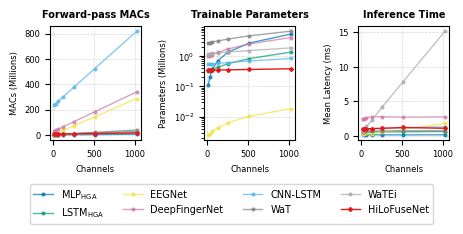

In [4]:
# --- Visualization ---
cm = 1 / 2.54
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12 * cm, 6 * cm))

target_color = '#E31A1C'
other_colors = [
    '#0072B2',
    '#009E73',
    '#F0E442',
    '#CC79A7',
    '#56B4E9',
    '#808080',
    '#A9A9A9'
]

model_renames = [r"MLP$_{\text{HGA}}$", r"LSTM$_{\text{HGA}}$", "EEGNet", "DeepFingerNet", "CNN-LSTM", "WaT", "WaTEi", "HiLoFuseNet"]

color_idx = 0
for idx, name in enumerate(model_names):
    data = results[name]
    # Filter out None values for plotting
    valid_indices = [i for i, val in enumerate(data["latency"]) if val is not None]
    plot_channels = [channel_counts[i] for i in valid_indices]

    # Highlight HiLoFuseNet with a thicker line and distinct color
    is_target = (name == "HiLoFuseNet")
    if is_target:
        current_color = target_color
        current_ms = 2
        current_marker = 'D'
        style = {
            'linewidth': 1,
            'alpha': 1.0,
            'zorder': 10,
            'color': current_color
        }
    else:
        current_color = other_colors[color_idx % len(other_colors)]
        current_ms = 2
        current_marker = 'o'
        style = {
            'linewidth': 1.0,
            'alpha': 0.7,
            'zorder': 5,
            'color': current_color
        }
        color_idx += 1
    marker = 'D' if is_target else 'o'

    rename = model_renames[idx]
    ax1.plot(plot_channels, [data["macs"][i] for i in valid_indices],
             label=rename, marker=marker, markersize=current_ms, **style)

    ax2.plot(plot_channels, [data["params"][i] for i in valid_indices],
             label=rename, marker=marker, markersize=current_ms, **style)

    ax3.plot(plot_channels, [data["latency"][i] for i in valid_indices],
             label=rename, marker=marker, markersize=current_ms, **style)

# Formatting
axes = [ax1, ax2, ax3]
titles = [ "Forward-pass MACs", "Trainable Parameters","Inference Time"]
y_labels = ["MACs (Millions)", "Parameters (Millions)","Mean Latency (ms)"]

for i, ax in enumerate(axes):
    ax.set_title(titles[i], fontsize=7, fontweight='bold')
    ax.set_ylabel(y_labels[i], fontsize=6)
    ax.set_xlabel("Channels", fontsize=6)
    ax.grid(True, ls='--', alpha=0.5)
    ax.tick_params(axis='both', labelsize=6)

ax2.set_yscale('log')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.22),
           ncol=4,
           fontsize=7,
           frameon=True)

plt.tight_layout(rect=[0, 0.18, 1, 1])

figPath = 'E:/my papers/finger decoding/HiLoFuseNet/manuscript/figures/'
plt.savefig(figPath+"model_scalability_comparison.png", dpi=300)
plt.show()